### 1. Colab 연동

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

file_path = '/content/drive/MyDrive/colab_ModelLoad.txt'

if os.path.exists(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        hf_token = f.read().strip()
    print("성공적으로 토큰을 불러왔습니다.")
else:
    assert(f"오류: '{file_path}' 경로에 파일이 없습니다. 경로를 다시 확인해주세요.")

from huggingface_hub import login
login(token=hf_token)

Mounted at /content/drive


### 2. 전역 설정 & 모델 로드

In [2]:
import os, io, time, json, pickle, socket, struct, threading, warnings
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Tuple
import torch
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
assert torch.cuda.is_available(), "Runtime > Hardware Accelerator > GPU"

# ============================================================
# 전역 설정  (실험 전 이 셀만 수정)
# ============================================================
MODEL_NAME     = "Qwen/Qwen2.5-7B-Instruct"
USE_4BIT       = True
MAX_NEW_TOKENS = 80
DEVICE         = "cuda"

# 네트워크 시나리오 (BW Gbps, RTT ms)
NETWORK_SCENARIOS = {
    "1GbE" : {"bw_gbps": 1.0,  "rtt_ms": 1.0},
    "10GbE": {"bw_gbps": 10.0, "rtt_ms": 0.5},
    "25GbE": {"bw_gbps": 25.0, "rtt_ms": 0.3},
}
WORKER_HOST, WORKER_PORT = "127.0.0.1", 50051

# Context-length sweep 범위
SEQ_SWEEP = [512, 1024, 2048, 4096, 8192]

TEST_PROMPT = (
    "Explain in detail how attention mechanisms work in transformer models, "
    "and how key-value caching speeds up autoregressive token generation:"
)

vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU  : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {vram_total:.1f} GB")

GPU  : Tesla T4
VRAM : 15.6 GB


In [ ]:
# ============================================================
# Phase 2: 모델 로드  (T4 기준 4-bit 양자화)
# ============================================================
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def load_model(model_name: str = MODEL_NAME, use_4bit: bool = USE_4BIT):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if use_4bit:
        bnb = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            model_name, quantization_config=bnb,
            device_map="auto", trust_remote_code=True,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_name, torch_dtype=torch.float16,
            device_map="auto", trust_remote_code=True,
        )
    model.eval()
    return model, tokenizer

model, tokenizer = load_model()
used = torch.cuda.memory_allocated() / 1e9
print(f"모델 로드 완료  |  VRAM {used:.2f} GB  |  잔여 {vram_total-used:.2f} GB")

### 3. 수학적 모델

In [3]:
# ============================================================
# Phase 1: 수학적 모델  (제안서 p.7 수식 구현)
# ============================================================
# 모든 수식은 Qwen2.5 7B 파라미터 기준
# N_layers=28, N_kv_heads=8 (GQA), d_head=128, float16

N_LAYERS   = 28     # Qwen2.5 7B
N_KV_HEADS = 8      # GQA
D_HEAD     = 128
DTYPE_BYTES = 2     # float16


N_LAYERS    = model.config.num_hidden_layers
N_KV_HEADS  = model.config.num_key_value_heads
D_HEAD      = model.config.hidden_size // model.config.num_attention_heads
DTYPE_BYTES = 2  # float16 — 4-bit 양자화해도 KV 캐시는 float16 유지

print(f"N_LAYERS   : {N_LAYERS}")
print(f"N_KV_HEADS : {N_KV_HEADS}  ← GQA (Query heads: {model.config.num_attention_heads})")
print(f"D_HEAD     : {D_HEAD}")
print(f"KV/token   : {kv_size(1)/1024:.2f} KB")
print(f"KV @ 2000  : {kv_size(2000)/1e6:.2f} MB")

# 수학적 모델 시각화 실제 파라미터로 다시 그리기
plot_theoretical()


def kv_size_bytes(seq_len: int) -> float:
    # Size(KV) = 2 * N_layers * N_kv_heads * d_head * L_seq * sizeof(dtype)
    return 2 * N_LAYERS * N_KV_HEADS * D_HEAD * seq_len * DTYPE_BYTES


def t_offload(seq_len: int, bw_pcie_eff_gbps: float = 8.0, t_cpu_ms: float = 0.3) -> float:
    # T_offload = Size(KV) / BW_PCIe_eff + T_cpu_access
    sz = kv_size_bytes(seq_len)
    return sz / (bw_pcie_eff_gbps * 1e9 / 8) + t_cpu_ms / 1e3


def t_dist(seq_len: int, bw_net_gbps: float, rtt_ms: float) -> float:
    # T_dist = Size(KV) / BW_net + RTT_net
    sz = kv_size_bytes(seq_len)
    return sz / (bw_net_gbps * 1e9 / 8) + rtt_ms / 1e3


def threshold_seq_len(bw_net_gbps: float, rtt_ms: float,
                      bw_pcie_eff_gbps: float = 8.0, t_cpu_ms: float = 0.3) -> Optional[float]:
    # T_dist < T_offload 를 L_seq 에 대해 풀면 분산 캐시가 유리해지는 임계 컨텍스트 길이
    # TODO: 부등식 전개 후 L_seq* 수식 도출 및 반환
    # 힌트: Size(KV) = k * L_seq 로 치환하면 선형 부등식
    raise NotImplementedError


def threshold_bw(seq_len: int, rtt_ms: float,
                 bw_pcie_eff_gbps: float = 8.0, t_cpu_ms: float = 0.3) -> float:
    # 분산 캐시가 유리하기 위한 최소 BW_net (Gbps)
    # TODO: T_dist < T_offload 를 BW_net 에 대해 풀어 반환
    raise NotImplementedError


# 이론값 테이블 출력 (구현 완료 후 주석 해제)
print(f"{'seq':>6}  {'KV(MB)':>8}  {'T_off(ms)':>10}", end="")
for n in NETWORK_SCENARIOS:
    print(f"  {n:>12}", end="")
print()
print("-" * 65)
for s in SEQ_SWEEP:
    row = f"{s:>6}  {kv_size_bytes(s)/1e6:>8.1f}  {t_offload(s)*1e3:>10.2f}"
    for n, sc in NETWORK_SCENARIOS.items():
        td = t_dist(s, sc['bw_gbps'], sc['rtt_ms']) * 1e3
        flag = "WIN" if td < t_offload(s)*1e3 else "---"
        row += f"  {flag} {td:>6.2f}ms"
    print(row)

   seq    KV(MB)   T_off(ms)          1GbE         10GbE         25GbE
-----------------------------------------------------------------
   512      58.7       59.02  --- 470.76ms  WIN  47.48ms  WIN  19.09ms
  1024     117.4      117.74  --- 940.52ms  WIN  94.45ms  WIN  37.88ms
  2048     234.9      235.18  --- 1880.05ms  WIN 188.40ms  WIN  75.46ms
  4096     469.8      470.06  --- 3759.10ms  WIN 376.31ms  WIN 150.62ms
  8192     939.5      939.82  --- 7517.19ms  WIN 752.12ms  WIN 300.95ms


### 4. 시각화

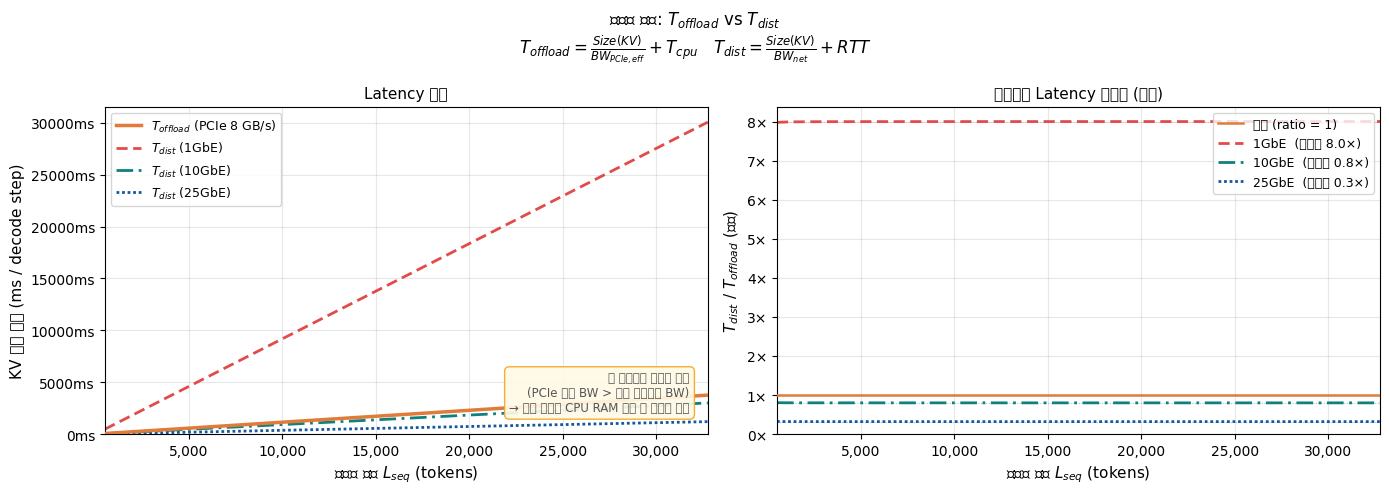

In [ ]:
def plot_theoretical():
    # TODO: 수학적 모델 시각화
    # 요구사항:
    #   1) x축: L_seq (512 ~ 32768), y축: latency (ms)
    #   2) T_offload 곡선 1개
    #   3) T_dist 곡선 3개 (1GbE / 10GbE / 25GbE)
    #   4) 교차점 (임계 L_seq) 에 수직선 표시
    raise NotImplementedError

# plot_theoretical()  # 구현 후 주석 해제

### 5. 시뮬레이션 구현

In [ ]:
# ============================================================
# Phase 3-A: 공통 자료구조 & KV 유틸리티
# ============================================================

@dataclass
class StepTiming:
    step_idx:      int
    total_s:       float
    model_fwd_s:   float
    kv_transfer_s: float   # PCIe 또는 네트워크 전송 시간
    kv_size_bytes: int


@dataclass
class BenchmarkResult:
    engine_name:      str
    ttft_s:           float
    tps:              float
    tokens_generated: int
    total_s:          float
    step_timings:     List[StepTiming] = field(default_factory=list)
    error:            Optional[str] = None

    @property
    def avg_kv_ms(self):
        if not self.step_timings: return 0.0
        return sum(s.kv_transfer_s for s in self.step_timings) / len(self.step_timings) * 1e3

    @property
    def kv_ratio(self):
        a = sum(s.kv_transfer_s for s in self.step_timings)
        b = sum(s.total_s for s in self.step_timings)
        return a / b if b > 0 else 0.0

    def summary(self):
        print(f"[{self.engine_name}]")
        print(f"  TTFT        : {self.ttft_s*1e3:.1f} ms")
        print(f"  TPS         : {self.tps:.3f} tokens/s")
        print(f"  avg KV 전송  : {self.avg_kv_ms:.1f} ms/step")
        print(f"  KV 전송 비율 : {self.kv_ratio*100:.1f}%")
        if self.error:
            print(f"  오류: {self.error}")


# ── KV 캐시 형식 변환 (DynamicCache <-> list) ───────────────────────────────
def kv_to_list(past_key_values) -> list:
    if past_key_values is None: return []
    if hasattr(past_key_values, "key_cache"):       # DynamicCache (transformers >= 4.36)
        return [(past_key_values.key_cache[i], past_key_values.value_cache[i])
                for i in range(len(past_key_values.key_cache))]
    return [(k, v) for k, v in past_key_values]     # legacy tuple

def list_to_kv(kv_list: list, device: str = "cuda"):
    try:
        from transformers import DynamicCache
        c = DynamicCache()
        c.key_cache   = [k.to(device) for k, v in kv_list]
        c.value_cache = [v.to(device) for k, v in kv_list]
        return c
    except ImportError:
        return tuple((k.to(device), v.to(device)) for k, v in kv_list)

def kv_bytes_actual(kv_list: list) -> int:
    return sum(k.element_size()*k.numel() + v.element_size()*v.numel()
               for k, v in kv_list)

print("자료구조 및 KV 유틸리티 정의 완료")

In [ ]:
# ============================================================
# Phase 3-B: BaseEngine  (공통 생성 루프 + 측정 로직)
# ============================================================

class BaseEngine(ABC):
    ENGINE_NAME = "base"

    def __init__(self, model, tokenizer, device=DEVICE, max_new_tokens=MAX_NEW_TOKENS):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_new_tokens = max_new_tokens

    @abstractmethod
    def _prefill(self, input_ids: torch.Tensor) -> Tuple[int, object]:
        # 프롬프트 처리 후 (first_token_id, kv_state) 반환
        # kv_state 형식은 엔진마다 다름
        #   SingleGPU: kv_list (GPU 텐서)
        #   CPUOffload: kv_list (CPU 텐서)
        #   NetworkCache: session_id (str)
        ...

    @abstractmethod
    def _decode_step(self, token_id: int, kv_state, step_idx: int) -> Tuple[int, object, StepTiming]:
        # 단일 decode 스텝 → (next_token_id, new_kv_state, timing)
        ...

    def _cleanup(self): pass

    def generate(self, prompt: str) -> BenchmarkResult:
        input_ids = self.tokenizer(prompt, return_tensors="pt")["input_ids"].to(self.device)

        # Prefill → TTFT
        t0 = time.perf_counter()
        try:
            first_id, kv_state = self._prefill(input_ids)
        except Exception as e:
            return BenchmarkResult(self.ENGINE_NAME, 0, 0, 0, 0, error=str(e))
        ttft = time.perf_counter() - t0

        # Decode loop
        generated, timings = [first_id], []
        eos = self.tokenizer.eos_token_id
        t_dec = time.perf_counter()
        for step in range(self.max_new_tokens - 1):
            try:
                nxt, kv_state, timing = self._decode_step(generated[-1], kv_state, step)
            except Exception as e:
                print(f"  decode error @ step {step}: {e}"); break
            timings.append(timing); generated.append(nxt)
            if nxt == eos: break
        t_end = time.perf_counter()
        self._cleanup()

        dt = t_end - t_dec
        return BenchmarkResult(
            engine_name=self.ENGINE_NAME, ttft_s=ttft,
            tps=(len(generated)-1)/dt if dt > 0 else 0,
            tokens_generated=len(generated), total_s=t_end-t0,
            step_timings=timings,
        )

print("BaseEngine 정의 완료")

### 5-1. 단일 GPU

In [ ]:
# ============================================================
# Phase 3-C: Case 1 — 단일 GPU  (VRAM Only)
# ============================================================

class SingleGPUEngine(BaseEngine):
    ENGINE_NAME = "Case1: Single GPU"

    def _prefill(self, input_ids):
        # TODO:
        #   1) model.forward(input_ids, use_cache=True) 실행
        #   2) logits[:, -1, :].argmax() 로 첫 토큰 추출
        #   3) past_key_values → kv_to_list() 변환 후 반환
        raise NotImplementedError

    def _decode_step(self, token_id, kv_list, step_idx):
        # TODO:
        #   1) t_fwd_start = time.perf_counter()
        #   2) model.forward(input_ids=[[token_id]], past_key_values=list_to_kv(...))
        #   3) t_fwd_end = time.perf_counter()
        #   4) kv_transfer_s = 0.0  (이동 없음)
        #   5) StepTiming 생성 후 반환
        raise NotImplementedError

print("SingleGPUEngine 정의 완료")

### 5-2. CPU offload

In [ ]:
# ============================================================
# Phase 3-D: Case 2 — CPU Offload  (PCIe 왕복)
# ============================================================

class CPUOffloadEngine(BaseEngine):
    ENGINE_NAME = "Case2: CPU Offload"

    def _prefill(self, input_ids):
        # TODO:
        #   1) GPU에서 prefill 수행
        #   2) kv_to_list(past_key_values) 로 list 변환
        #   3) [(k.cpu(), v.cpu()) for k, v in kv_list]  (CPU 오프로드)
        #   4) torch.cuda.empty_cache()
        #   5) first_token_id, kv_cpu 반환
        raise NotImplementedError

    def _decode_step(self, token_id, kv_cpu, step_idx):
        # TODO: 아래 순서로 시간 측정
        #
        #   [전송 측정 시작]
        #   t_up0 = time.perf_counter()
        #   kv_gpu = [(k.to(device), v.to(device)) for k, v in kv_cpu]  # CPU -> GPU
        #   t_up1 = time.perf_counter()
        #
        #   [Forward]
        #   t_f0 = time.perf_counter()
        #   out  = model.forward(...)
        #   torch.cuda.synchronize()
        #   t_f1 = time.perf_counter()
        #
        #   [전송 측정]
        #   t_dn0 = time.perf_counter()
        #   new_kv_cpu = [(k.cpu(), v.cpu()) for ...]  # GPU -> CPU
        #   torch.cuda.empty_cache()
        #   t_dn1 = time.perf_counter()
        #
        #   kv_transfer_s = (t_up1-t_up0) + (t_dn1-t_dn0)
        #   model_fwd_s   = t_f1 - t_f0
        raise NotImplementedError

print("CPUOffloadEngine 정의 완료")

### 5-3. 분산 네트워크 방식

In [ ]:
# ============================================================
# Phase 3-E: KV Cache 워커 서버 & 클라이언트
#            (원격 노드 시뮬레이션 — 소켓 + time.sleep BW 에뮬레이션)
# ============================================================

def _send_bytes(sock, data: bytes):
    sock.sendall(struct.pack(">Q", len(data)) + data)

def _recv_exactly(sock, n: int) -> bytes:
    buf = bytearray()
    while len(buf) < n:
        chunk = sock.recv(n - len(buf))
        if not chunk: raise ConnectionError("소켓 연결 끊김")
        buf.extend(chunk)
    return bytes(buf)

def _recv_bytes(sock) -> bytes:
    return _recv_exactly(sock, struct.unpack(">Q", _recv_exactly(sock, 8))[0])


class KVCacheServer:
    # 대역폭 시뮬레이션: time.sleep(data_size / (bw_gbps * 1e9/8))
    # RTT 시뮬레이션   : time.sleep(rtt_ms / 2 / 1000)  (단방향)

    def __init__(self, host=WORKER_HOST, port=WORKER_PORT,
                 bw_gbps: float = 1.0, rtt_ms: float = 1.0):
        self.host, self.port = host, port
        self.bw_gbps, self.rtt_ms = bw_gbps, rtt_ms
        self._store: Dict[str, bytes] = {}
        self._lock   = threading.Lock()
        self._stats  = {"put": 0, "get": 0, "bytes_in": 0, "bytes_out": 0}
        self._running = False

    def _simulate(self, n_bytes: int):
        # TODO: 대역폭 + RTT 지연 구현
        # time.sleep(n_bytes / (self.bw_gbps * 1e9 / 8) + self.rtt_ms / 2e3)
        raise NotImplementedError

    def _handle(self, conn, addr):
        # TODO: PUT / GET / DEL / PING 명령 처리 루프
        # 프로토콜: pickle({cmd, key, payload}) <-> pickle({ok, payload})
        # PUT: _simulate(len(payload)) 후 self._store[key] = payload
        # GET: self._store.get(key) 가져온 후 _simulate(len(payload))
        raise NotImplementedError

    def start(self):
        # TODO: TCP 서버 소켓 바인드 후 accept 루프를 daemon 스레드로 실행
        raise NotImplementedError

    def stop(self):
        # TODO: self._running = False, 소켓 닫기, 스레드 join
        raise NotImplementedError

    def get_stats(self): return dict(self._stats)


class KVCacheClient:
    def __init__(self, host=WORKER_HOST, port=WORKER_PORT):
        self.host, self.port = host, port
        self._sock = None

    def connect(self):
        # TODO: TCP 소켓 연결
        raise NotImplementedError

    def disconnect(self):
        # TODO: 소켓 닫기
        raise NotImplementedError

    def put(self, key: str, kv_list: list):
        # TODO:
        #   1) kv_list -> [(k.cpu(), v.cpu()), ...] 변환 후 torch.save -> bytes
        #   2) pickle({cmd:"PUT", key:key, payload:bytes}) 전송
        #   3) 응답 수신 및 ok 확인
        raise NotImplementedError

    def get(self, key: str) -> list:
        # TODO:
        #   1) pickle({cmd:"GET", key:key}) 전송
        #   2) 응답 수신 -> torch.load -> [(k, v), ...] 반환
        raise NotImplementedError

    def delete(self, key: str):
        # TODO: {cmd:"DEL", key:key} 전송
        raise NotImplementedError

print("KVCacheServer / KVCacheClient 스켈레톤 정의 완료")

In [ ]:
# ============================================================
# Phase 3-F: Case 3 — Network Cache  (제안 방식)
# ============================================================
import uuid

class NetworkCacheEngine(BaseEngine):
    ENGINE_NAME = "Case3: Network Cache"

    def __init__(self, *args, client: KVCacheClient, **kwargs):
        super().__init__(*args, **kwargs)
        self._client = client
        self._sid    = f"kv_{uuid.uuid4().hex[:8]}"

    def _prefill(self, input_ids):
        # TODO:
        #   1) GPU에서 prefill 수행
        #   2) kv_to_list(past_key_values)
        #   3) self._client.put(self._sid, kv_list)  -> 서버에 저장
        #   4) torch.cuda.empty_cache()
        #   5) first_token_id, self._sid 반환  (kv_state = 세션 ID)
        raise NotImplementedError

    def _decode_step(self, token_id, sid, step_idx):
        # TODO: 아래 순서로 시간 측정
        #
        #   [수신 측정 시작]
        #   t_rx0 = time.perf_counter()
        #   kv_cpu = self._client.get(sid)          # 서버에서 KV 수신
        #   kv_gpu = [(k.to(device), v.to(device)) for k, v in kv_cpu]
        #   t_rx1 = time.perf_counter()
        #
        #   [Forward]
        #   t_f0 = time.perf_counter()
        #   out  = model.forward(...)
        #   torch.cuda.synchronize()
        #   t_f1 = time.perf_counter()
        #
        #   [송신 측정]
        #   t_tx0 = time.perf_counter()
        #   self._client.put(sid, kv_to_list(out.past_key_values))
        #   torch.cuda.empty_cache()
        #   t_tx1 = time.perf_counter()
        #
        #   kv_transfer_s = (t_rx1-t_rx0) + (t_tx1-t_tx0)
        raise NotImplementedError

    def _cleanup(self):
        try: self._client.delete(self._sid)
        except: pass

print("NetworkCacheEngine 스켈레톤 정의 완료")

### 6. 단일 실험 비교

In [ ]:
# ============================================================
# Phase 4: 단일 실험  (3가지 Case 비교 — ACTIVE_SCENARIO 기준)
# ============================================================
ACTIVE_SCENARIO = "1GbE"
COMMON = dict(model=model, tokenizer=tokenizer,
              device=DEVICE, max_new_tokens=MAX_NEW_TOKENS)
RESULTS: Dict[str, BenchmarkResult] = {}

# -- Case 1: Single GPU --
# TODO: SingleGPUEngine 구현 후 주석 해제
# r1 = SingleGPUEngine(**COMMON).generate(TEST_PROMPT)
# RESULTS["case1"] = r1; torch.cuda.empty_cache()
# r1.summary()

# -- Case 2: CPU Offload --
# TODO: CPUOffloadEngine 구현 후 주석 해제
# r2 = CPUOffloadEngine(**COMMON).generate(TEST_PROMPT)
# RESULTS["case2"] = r2; torch.cuda.empty_cache()
# r2.summary()

# -- Case 3: Network Cache --
# TODO: KVCacheServer / Client / NetworkCacheEngine 구현 후 주석 해제
# sc = NETWORK_SCENARIOS[ACTIVE_SCENARIO]
# server = KVCacheServer(bw_gbps=sc["bw_gbps"], rtt_ms=sc["rtt_ms"])
# server.start(); time.sleep(0.3)
# client = KVCacheClient(); client.connect()
# r3 = NetworkCacheEngine(**COMMON, client=client).generate(TEST_PROMPT)
# RESULTS["case3"] = r3
# client.disconnect(); server.stop(); torch.cuda.empty_cache()
# r3.summary()

print("단일 실험 셀 준비 완료 — 각 TODO 구현 후 주석 해제")